# Test file for CIC-IDS2017 model creation and analysis

### 1. Data loading

In [1]:
import pandas as pd
import polars as pl
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from datetime import datetime
from datetime import timedelta

import pandas as pd
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

pd.options.display.max_rows = 80

In [2]:
# read data

#get dataset size for comparison
file_path = '/mnt/AI-DATA/alara/CiberIA_O1_A1/Data/CIC-IDS2017.csv'
file_size = os.path.getsize(file_path)
print(f"Dataset size: {file_size / (1024 * 1024):.2f} MB")

start_time = datetime.now()
print("Reading data with Polars...")
df_pl = pl.read_csv(file_path, low_memory=False)
print("Data read using Polars in", datetime.now() - start_time) 

Dataset size: 1472.67 MB
Reading data with Polars...
Data read using Polars in 0:00:00.388676


In [3]:
start_time = datetime.now()
print("Reading data with Polars...")
df_pl = pl.read_csv(file_path, low_memory=False)
print("Data read using Polars in", datetime.now() - start_time) 

Reading data with Polars...
Data read using Polars in 0:00:00.365665


### 2. Data exploration

In [21]:
from IPython.display import display
#display(df_pd.head())
display(df_pl.head())

Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,…,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Type
str,str,f64,str,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""192.168.10.5-8.254.250.126-491…","""8.254.250.126""",80.0,"""192.168.10.5""",49188.0,6.0,"""03/07/2017 08:55:58""",4.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,3e6,500000.0,4.0,0.0,4.0,4.0,4.0,4.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,329.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""BENIGN"""
"""192.168.10.5-8.254.250.126-491…","""8.254.250.126""",80.0,"""192.168.10.5""",49188.0,6.0,"""03/07/2017 08:55:58""",1.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,1.2e7,2e6,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,329.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""BENIGN"""
"""192.168.10.14-8.253.185.121-49…","""8.253.185.121""",80.0,"""192.168.10.14""",49486.0,6.0,"""03/07/2017 08:56:22""",3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,4e6,666666.666667,3.0,0.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,245.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""BENIGN"""
"""192.168.10.14-8.253.185.121-49…","""8.253.185.121""",80.0,"""192.168.10.14""",49486.0,6.0,"""03/07/2017 08:56:22""",1.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,0.0,0.0,0.0,0.0,1.2e7,2e6,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,9.0,6.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0.0,245.0,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""BENIGN"""
"""192.168.10.3-192.168.10.9-88-1…","""192.168.10.9""",1031.0,"""192.168.10.3""",88.0,6.0,"""03/07/2017 08:56:38""",609.0,7.0,4.0,484.0,414.0,233.0,0.0,69.142857,111.967895,207.0,0.0,103.5,119.511506,1.4745e6,18062.397373,60.9,115.194956,381.0,2.0,609.0,101.5,177.089525,460.0,2.0,467.0,155.666667,263.560872,460.0,3.0,0.0,…,11562.151515,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,81.636364,69.142857,103.5,164.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,484.0,4.0,414.0,8192.0,2053.0,5.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""BENIGN"""


In [4]:
start_time = datetime.now()
print("Converting Polars DataFrame to Pandas DataFrame...")

try:
    df = df_pl.to_pandas()
    print("Conversion completed in", datetime.now() - start_time)
except Exception as e:
    print("Conversion failed:", e)

Converting Polars DataFrame to Pandas DataFrame...
Conversion completed in 0:00:00.731041


In [23]:
print('Cantidad de Filas y columnas:',df.shape)
print('Nombre columnas:',df.columns)

Cantidad de Filas y columnas: (2830540, 85)
Nombre columnas: Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min 

In [5]:
# remove 'Infiltration' and 'Heartbleed' classes
df = df[~df['Attack Type'].isin(['Infiltration', 'Heartbleed'])]
print("Data shape:", df.shape)
print("Data columns:", df.columns)

Data shape: (2830493, 85)
Data columns: Index(['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
       'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration',
       'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max 

### 4. Data visualization


In [6]:
df['Attack Type'].value_counts()

Attack Type
BENIGN         2272895
DoS             252660
Port Scan       158930
DDoS            128027
Brute Force      13835
Web Attack        2180
Bot               1966
Name: count, dtype: int64

In [6]:
print("Encoding attack types...")
le = LabelEncoder()
df['Attack Number'] = le.fit_transform(df['Attack Type'])
print("Encoded attack classes:")
for val in sorted(df['Attack Number'].unique()):
    print(f"{val}: {le.inverse_transform([val])[0]}")

print("Number of samples of each attack type:")
print(df['Attack Type'].value_counts())

Encoding attack types...
Encoded attack classes:
0: BENIGN
1: Bot
2: Brute Force
3: DDoS
4: DoS
5: Port Scan
6: Web Attack
Number of samples of each attack type:
Attack Type
BENIGN         2272895
DoS             252660
Port Scan       158930
DDoS            128027
Brute Force      13835
Web Attack        2180
Bot               1966
Name: count, dtype: int64


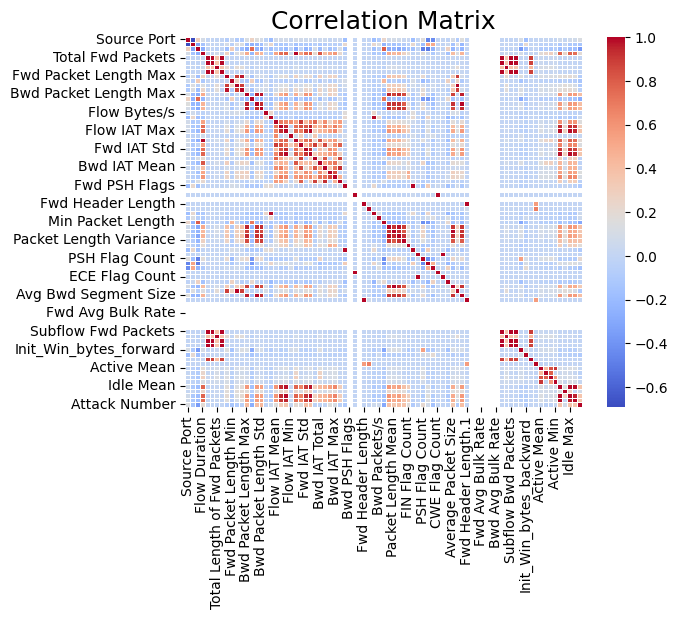

In [15]:
corr = df.corr(numeric_only = True).round(2)
corr.style.background_gradient(cmap = 'coolwarm', axis = None).format(precision = 2)

fig, ax = plt.subplots(figsize = (24, 24))
sns.heatmap(corr, cmap = 'coolwarm', annot = False, linewidth = 0.5)
plt.title('Correlation Matrix', fontsize = 18)
plt.show()

In [16]:
pos_corr_features = corr['Attack Number'][(corr['Attack Number'] > 0) & (corr['Attack Number'] < 1)].index.tolist()
# ordenador por valor absoluto
pos_corr_features.sort(key = lambda x: abs(corr.loc[x, 'Attack Number']), reverse = True)

print("Features with positive correlation with 'Attack Number':\n")
for i, feature in enumerate(pos_corr_features, start = 1):
    corr_value = corr.loc[feature, 'Attack Number']
    print('{:<3} {:<24} :{}'.format(f'{i}.', feature, corr_value))

print(f'Number of considerable important features: {len(pos_corr_features)}')

Features with positive correlation with 'Attack Number':

1.  Bwd Packet Length Std    :0.43
2.  Bwd Packet Length Max    :0.41
3.  Bwd Packet Length Mean   :0.4
4.  Avg Bwd Segment Size     :0.4
5.  Fwd IAT Std              :0.39
6.  Packet Length Std        :0.39
7.  Max Packet Length        :0.38
8.  Packet Length Variance   :0.37
9.  Idle Mean                :0.37
10. Idle Max                 :0.37
11. Flow IAT Max             :0.36
12. Fwd IAT Max              :0.36
13. Idle Min                 :0.36
14. Packet Length Mean       :0.34
15. Average Packet Size      :0.33
16. Flow IAT Std             :0.31
17. PSH Flag Count           :0.21
18. Fwd IAT Total            :0.2
19. Flow Duration            :0.19
20. FIN Flag Count           :0.18
21. Flow IAT Mean            :0.16
22. Bwd IAT Std              :0.15
23. Fwd IAT Mean             :0.14
24. Source Port              :0.13
25. Bwd IAT Max              :0.11
26. ACK Flag Count           :0.08
27. Idle Std                 :0.08


### 5. Data preprocessing

In [7]:
# For improving performance and reduce memory-related errors
old_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f'Initial memory usage: {old_memory_usage:.2f} MB')
for col in df.columns:
    col_type = df[col].dtype
    if col_type != object:
        c_min = df[col].min()
        c_max = df[col].max()
        # Downcasting float64 to float32
        if str(col_type).find('float') >= 0 and c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
            df[col] = df[col].astype(np.float32)

        # Downcasting int64 to int32
        elif str(col_type).find('int') >= 0 and c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
            df[col] = df[col].astype(np.int32)

new_memory_usage = df.memory_usage().sum() / 1024 ** 2
print(f"Final memory usage: {new_memory_usage:.2f} MB")

# Calculating percentage reduction in memory usage
print(f'Reduced memory usage: {1 - (new_memory_usage / old_memory_usage):.2%}')

Initial memory usage: 1878.76 MB
Final memory usage: 1004.17 MB
Reduced memory usage: 46.55%


In [8]:
# Dropping columns with only one unique value
num_unique = df.nunique()
one_variable = num_unique[num_unique == 1]
not_one_variable = num_unique[num_unique > 1].index

dropped_cols = one_variable.index
data = df[not_one_variable]

print('Dropped columns:')
dropped_cols

Dropped columns:


Index(['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk',
       'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
       'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [9]:
# save only numerical data
attacks = data['Attack Type']
data = data.select_dtypes(include = ['float32', 'int32'])

In [10]:
data.drop(columns = ['Attack Number'], inplace = True)

#### PCA

In [12]:
# Standardizing the dataset
from sklearn.preprocessing import StandardScaler

features = data

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

from sklearn.decomposition import IncrementalPCA

size = len(data.columns) // 2
pca = PCA(n_components=size)
transformed_features = pca.fit_transform(scaled_features)
print(f'Information retained: {sum(pca.explained_variance_ratio_):.2%}')
new_data_pca = pd.DataFrame(transformed_features, columns=[f'PC{i+1}' for i in range(size)])
new_data_pca['Attack Type'] = attacks.values

new_data_pca

Information retained: 99.40%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,Attack Type
0,-2.173499,-0.015486,0.258049,2.880306,-2.738894,-0.970891,-0.096462,-0.435404,-0.238442,1.277897,...,-0.063836,1.315308,-0.775577,-0.331045,-0.091399,-0.473023,0.043729,0.005783,-0.031520,BENIGN
1,-2.614151,-0.019950,0.377499,4.757193,-5.030467,-1.826172,-0.304937,-1.641705,1.740941,-2.637693,...,-0.023382,1.514211,-1.202271,-0.594836,0.088595,-0.668903,0.063130,0.005819,-0.146333,BENIGN
2,-2.223236,-0.015982,0.271875,3.093147,-2.996046,-1.069712,-0.120008,-0.571400,-0.018926,0.847198,...,-0.059443,1.344737,-0.819595,-0.351093,-0.075278,-0.496402,0.046097,0.005805,-0.043665,BENIGN
3,-2.614926,-0.019950,0.378052,4.761491,-5.033000,-1.829962,-0.305319,-1.643668,1.740525,-2.633326,...,-0.023484,1.521539,-1.198879,-0.585573,0.084716,-0.670518,0.063341,0.005837,-0.145721,BENIGN
4,-1.358795,0.102159,-0.636521,0.863909,-0.132121,0.925816,0.202037,1.211372,-0.505598,-0.245886,...,-0.380579,0.112216,-0.631424,-1.291166,0.567733,0.142001,-0.040652,-0.000012,0.012946,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830488,-2.104664,-0.010922,0.223730,2.336258,-1.944241,-0.976966,-0.042639,-0.102734,-0.953130,3.084570,...,0.209793,1.053033,-0.296984,0.342124,-0.217162,-0.198557,0.014712,0.002908,0.015725,BENIGN
2830489,-2.101898,-0.010905,0.223241,2.328221,-1.934248,-0.973756,-0.042092,-0.099719,-0.956231,3.091597,...,0.211734,1.054810,-0.297241,0.344707,-0.216159,-0.196727,0.014380,0.002894,0.016032,BENIGN
2830490,-2.101276,-0.010903,0.223131,2.326376,-1.932001,-0.973012,-0.041969,-0.099046,-0.956913,3.093107,...,0.212150,1.055129,-0.297338,0.345148,-0.215890,-0.196297,0.014303,0.002891,0.016096,BENIGN
2830491,-1.956192,-0.009226,0.134095,1.918257,-1.794452,-0.394702,-0.021461,-0.046626,-0.486865,1.189542,...,-0.216026,0.012902,0.863530,1.013420,-0.394287,0.122344,-0.006567,0.001075,0.119125,BENIGN


In [11]:
# select k best features
from sklearn.feature_selection import SelectKBest, f_classif

features = data
target = attacks

k = 32
selector = SelectKBest(f_classif, k = k)
selector.fit(features, target)

selected_features = features.columns[selector.get_support()]
selected_features

print(f'Selected Features: {selected_features}')

# save selected features
new_data_k_20 = data[selected_features]
new_data_k_20['Attack Type'] = attacks.values

print(new_data_k_20.head())

Selected Features: Index(['Destination Port', 'Protocol', 'Flow Duration',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean',
       'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Std', 'Bwd IAT Max',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'Down/Up Ratio',
       'Average Packet Size', 'Avg Bwd Segment Size', 'Init_Win_bytes_forward',
       'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'],
      dtype='object')
   Destination Port  Protocol  Flow Duration  Bwd Packet Length Max  \
0           49188.0       6.0            4.0                    0.0   
1           49188.0       6.0            1.0                    0.0   
2           49486.0       6.0            3.0                    0.0   
3       

/tmp/ipykernel_130340/1570902532.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_data_k_20['Attack Type'] = attacks.values


### 5. Model training

##### Binary classification

In [78]:
# For cross validation
from sklearn.model_selection import cross_val_score

In [79]:
# Creating a balanced dataset for Binary Classification
normal_traffic = new_data_pca.loc[new_data_pca['Attack Type'] == 'BENIGN']
intrusions = new_data_pca.loc[new_data_pca['Attack Type'] != 'BENIGN']

normal_traffic = normal_traffic.sample(n = len(intrusions), replace = False)

ids_data = pd.concat([intrusions, normal_traffic])
ids_data['Attack Type'] = np.where((ids_data['Attack Type'] == 'BENIGN'), 0, 1)
bc_data = ids_data.sample(n = 15000)

print(bc_data['Attack Type'].value_counts())

Attack Type
1    7535
0    7465
Name: count, dtype: int64


In [80]:
# Splitting the data into features (X) and target (y)
from sklearn.model_selection import train_test_split

X_bc = bc_data.drop('Attack Type', axis = 1)
y_bc = bc_data['Attack Type']

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(X_bc, y_bc, test_size = 0.25, random_state = 0)

#### Logistic Regression

Logistic regression Model 1

Cross-validation scores: 0.9986666666666667, 0.9964444444444445, 0.9977777777777778, 0.9973333333333333, 0.9991111111111111

Mean cross-validation score: 1.00
Logistic regression Model 1

Classification Report:
              precision    recall  f1-score   support

           0     0.9979    0.9995    0.9987      1871
           1     0.9995    0.9979    0.9987      1879

    accuracy                         0.9987      3750
   macro avg     0.9987    0.9987    0.9987      3750
weighted avg     0.9987    0.9987    0.9987      3750

Logistic regression Model 1

Confusion Matrix:


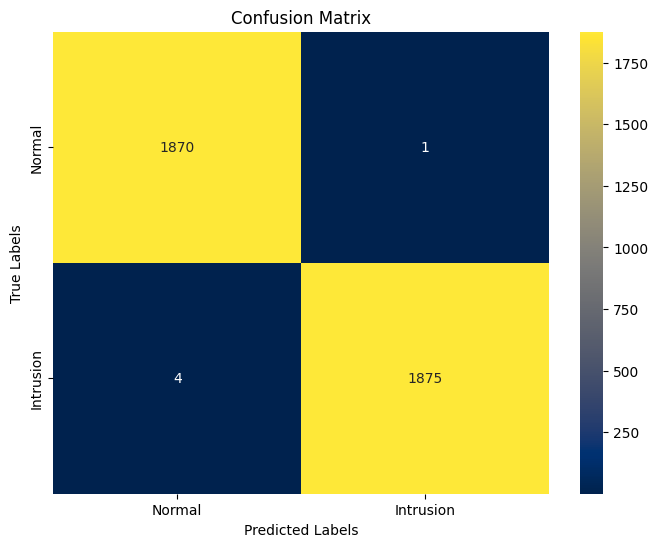

In [81]:
from sklearn.linear_model import LogisticRegression

lr1 = LogisticRegression(max_iter = 10000, C = 0.1, random_state = 0, solver = 'saga')
lr1.fit(X_train_bc, y_train_bc)

cv_lr1 = cross_val_score(lr1, X_train_bc, y_train_bc, cv = 5)
print('Logistic regression Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_lr1)))
print(f'\nMean cross-validation score: {cv_lr1.mean():.2f}')

from sklearn.metrics import classification_report

y_pred_lr1 = lr1.predict(X_test_bc)
print('Logistic regression Model 1')
print('\nClassification Report:')
print(classification_report(y_test_bc, y_pred_lr1, digits=4))

from sklearn.metrics import confusion_matrix

cm_lr1 = confusion_matrix(y_test_bc, y_pred_lr1)
print('Logistic regression Model 1')
print('\nConfusion Matrix:')

plt.figure(figsize = (8, 6))
sns.heatmap(cm_lr1, annot = True, fmt = 'd', cmap = 'cividis', xticklabels = ['Normal', 'Intrusion'], yticklabels = ['Normal', 'Intrusion'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#### SVM

Support Vector Machine Model 1

Cross-validation scores: 0.9977777777777778, 0.9973333333333333, 0.9986666666666667, 0.9968888888888889, 0.9986666666666667

Mean cross-validation score: 1.00
Support Vector Machine Model 1

Classification Report:
              precision    recall  f1-score   support

           0     0.9968    0.9995    0.9981      1871
           1     0.9995    0.9968    0.9981      1879

    accuracy                         0.9981      3750
   macro avg     0.9981    0.9981    0.9981      3750
weighted avg     0.9981    0.9981    0.9981      3750

Support Vector Machine Model 1

Confusion Matrix:


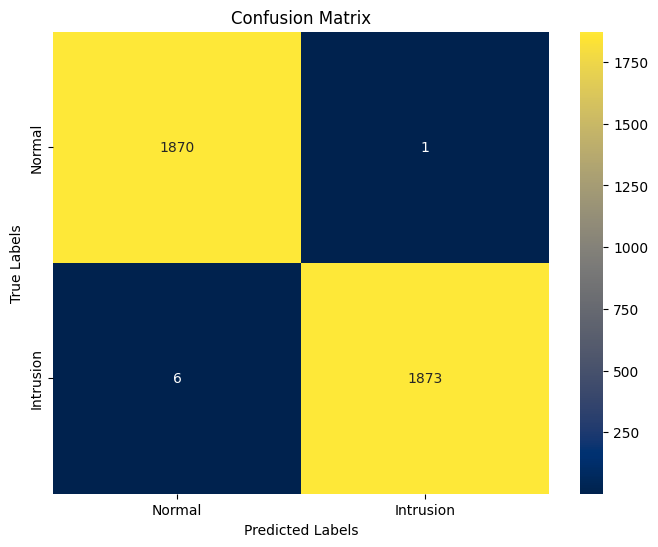

In [82]:
from sklearn.svm import SVC

svm1 = SVC(kernel = 'rbf', C = 1, random_state = 0, probability = True)
svm1.fit(X_train_bc, y_train_bc)

cv_svm1 = cross_val_score(svm1, X_train_bc, y_train_bc, cv = 5)
print('Support Vector Machine Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_svm1)))
print(f'\nMean cross-validation score: {cv_svm1.mean():.2f}')

# classification report
y_pred_svm1 = svm1.predict(X_test_bc)
print('Support Vector Machine Model 1')
print('\nClassification Report:')
print(classification_report(y_test_bc, y_pred_svm1, digits=4))

# confusion matrix
cm_svm1 = confusion_matrix(y_test_bc, y_pred_svm1)
print('Support Vector Machine Model 1')
print('\nConfusion Matrix:')
plt.figure(figsize = (8, 6))
sns.heatmap(cm_svm1, annot = True, fmt = 'd', cmap = 'cividis', xticklabels = ['Normal', 'Intrusion'], yticklabels = ['Normal', 'Intrusion'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#### Neural Network

2025-06-05 15:49:32.373192: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-05 15:49:32.385080: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749131372.397912 3624479 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749131372.401678 3624479 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749131372.411925 3624479 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Epoch 1/50


I0000 00:00:1749131380.525154 3625036 service.cc:152] XLA service 0x7f6e48004450 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749131380.525181 3625036 service.cc:160]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
I0000 00:00:1749131380.525184 3625036 service.cc:160]   StreamExecutor device (1): NVIDIA L40S, Compute Capability 8.9
I0000 00:00:1749131380.525187 3625036 service.cc:160]   StreamExecutor device (2): NVIDIA L40S, Compute Capability 8.9
I0000 00:00:1749131380.525188 3625036 service.cc:160]   StreamExecutor device (3): NVIDIA L40S, Compute Capability 8.9
2025-06-05 15:49:40.547878: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749131380.680024 3625036 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/44 ━━━━━━━━━━━━━━━━━━━━ 1:51 3s/step - accuracy: 0.5703 - loss: 0.8971

I0000 00:00:1749131382.414829 3625036 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-06-05 15:49:43.447612: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1048', 196 bytes spill stores, 196 bytes spill loads



44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7409 - loss: 0.5740

2025-06-05 15:49:45.661157: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_55', 4 bytes spill stores, 4 bytes spill loads

2025-06-05 15:49:45.767769: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 12 bytes spill stores, 12 bytes spill loads

2025-06-05 15:49:45.807075: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 8 bytes spill stores, 8 bytes spill loads

2025-06-05 15:49:45.959941: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 112 bytes spill stores, 112 bytes spill loads

2025-06-05 15:49:47.520307: I external/local_xla/x

44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.7432 - loss: 0.5700 - val_accuracy: 0.9859 - val_loss: 0.0803
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9668 - loss: 0.1361 - val_accuracy: 0.9925 - val_loss: 0.0249
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9832 - loss: 0.0679 - val_accuracy: 0.9968 - val_loss: 0.0145
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9887 - loss: 0.0464 - val_accuracy: 0.9973 - val_loss: 0.0105
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9928 - loss: 0.0309 - val_accuracy: 0.9976 - val_loss: 0.0079
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9941 - loss: 0.0251 - val_accuracy: 0.9976 - val_loss: 0.0061
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9951 - loss: 0.0248 - val_accuracy: 0.9979 - val_loss: 0.0055
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9951 - loss: 0.0161 - val_accuracy: 0.9979 - val_loss: 0.0044
E

2025-06-05 15:50:01.116353: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 12 bytes spill stores, 12 bytes spill loads

2025-06-05 15:50:01.117848: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_48', 4 bytes spill stores, 4 bytes spill loads



118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 1.0000 - loss: 1.5784e-05
Test Accuracy: 1.00


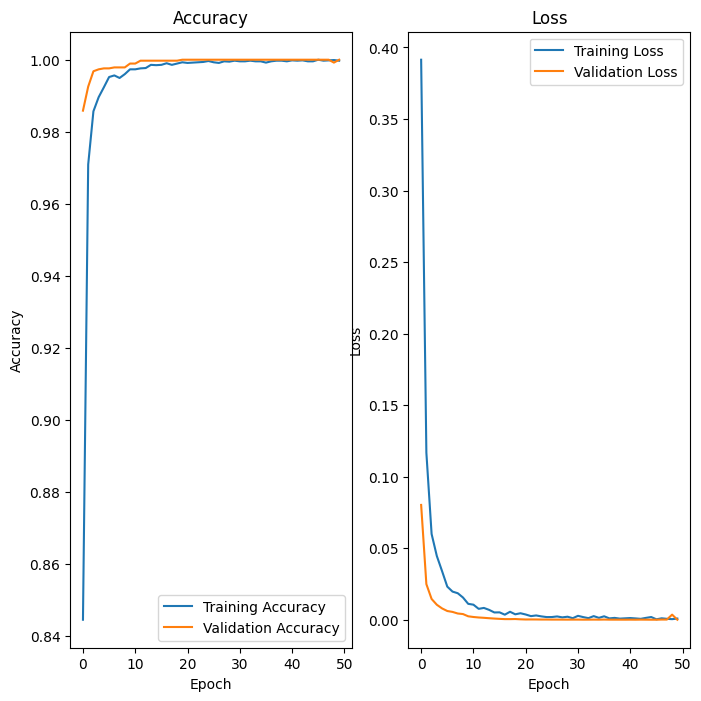

In [37]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# one hot encoding witout using to_categorical
y_test_cat = pd.get_dummies(y_test_bc)
y_train_cat = pd.get_dummies(y_train_bc)

# Define the model
model = Sequential()
model.add(Dense(128, input_dim=X_train_bc.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(y_train_cat.shape[1], activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_bc, y_train_cat, epochs=50, batch_size=256, validation_data=(X_test_bc, y_test_cat))

# Evaluate the model
loss, accuracy = model.evaluate(X_test_bc, y_test_cat)
print(f'Test Accuracy: {accuracy:.2f}')

# plot accuracy and loss across epochs
plt.figure(figsize=(8, 8))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      1907
           1     1.0000    1.0000    1.0000      1843

    accuracy                         1.0000      3750
   macro avg     1.0000    1.0000    1.0000      3750
weighted avg     1.0000    1.0000    1.0000      3750



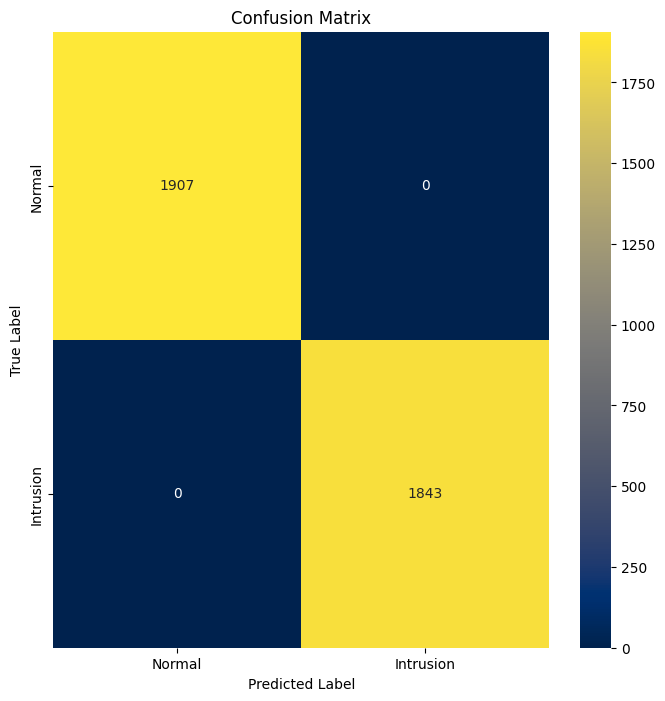

In [38]:
# matrix confusion
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test_bc)
y_pred = np.argmax(y_pred, axis=1)
y_test = np.argmax(y_test_cat.values, axis=1)

print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis', xticklabels=['Normal', 'Intrusion'], yticklabels=['Normal', 'Intrusion'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

##### Multi-class classification

In [14]:
new_data_pca['Attack Type'].value_counts()

Attack Type
BENIGN         2272895
DoS             252660
Port Scan       158930
DDoS            128027
Brute Force      13835
Web Attack        2180
Bot               1966
Name: count, dtype: int64

In [12]:
from imblearn.over_sampling import SMOTE

#######################################################################

class_counts = new_data_k_20['Attack Type'].value_counts()
selected_classes = class_counts[class_counts > 1950]
class_names = selected_classes.index
selected = new_data_k_20[new_data_k_20['Attack Type'].isin(class_names)]

dfs = []
for name in class_names:
  df = selected[selected['Attack Type'] == name]
  if len(df) > 2500:
    df = df.sample(n = 10000, random_state = 0)

  dfs.append(df)

df = pd.concat(dfs, ignore_index = True)

X = df.drop('Attack Type', axis=1)
y = df['Attack Type']

smote = SMOTE(sampling_strategy='auto', random_state=0)
X_upsampled, y_upsampled = smote.fit_resample(X, y)

blnc_data = pd.DataFrame(X_upsampled)
blnc_data['Attack Type'] = y_upsampled
blnc_data = blnc_data.sample(frac=1)

features = blnc_data.drop('Attack Type', axis = 1)
labels = blnc_data['Attack Type']

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size = 0.3, random_state = 0)

In [33]:
# save X_train, X_test, y_train, y_test in a variable
data_split = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test
}
# save the data_split variable to a file
import pickle
with open('/mnt/AI-DATA/alara/CiberIA_O1_A1/Framework/data_split_2017.pkl', 'wb') as f:
    pickle.dump(data_split, f)

#### Random Forest

#### LGBM

LightGBM Model

Cross-validation scores: 1.0, 1.0, 1.0, 1.0, 1.0

Mean cross-validation score: 1.00

Execution time: 9.01 seconds
LightGBM Model

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      2941
         Bot       1.00      1.00      1.00      3004
 Brute Force       1.00      1.00      1.00      2994
        DDoS       1.00      1.00      1.00      3031
         DoS       1.00      1.00      1.00      2962
   Port Scan       1.00      1.00      1.00      3001
  Web Attack       1.00      1.00      1.00      3067

    accuracy                           1.00     21000
   macro avg       1.00      1.00      1.00     21000
weighted avg       1.00      1.00      1.00     21000

LightGBM Model

Confusion Matrix:


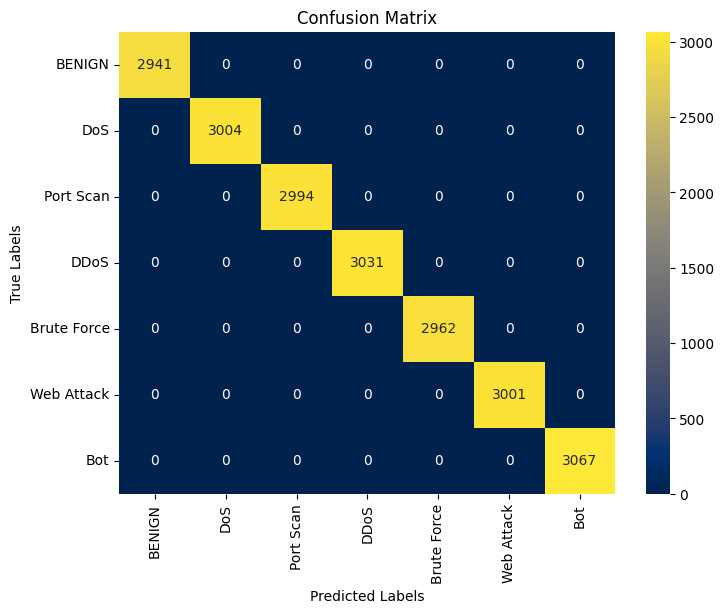

In [41]:
import lightgbm as lgbm
from time import time

# Parameters for LightGBM
params = {
    'min_gain_to_split': 0.0,  # Lowering the threshold for splits
    'min_child_samples': 10,   # Preventing overfitting by controlling sample count per leaf
    'min_data_in_leaf': 20,    # Ensures enough data per leaf
    'num_leaves': 31,
    'max_depth': 10,
    'random_state': 0,
    'verbose': -1
}

# Create model for multiclass classification
lgb_clf = lgbm.LGBMClassifier(**params)

# Train the models
lgb_clf.fit(X_train, y_train)

start_time = time()
cv_lgb = cross_val_score(lgb_clf, X_train, y_train, cv = 5)
print('LightGBM Model')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_lgb)))
print(f'\nMean cross-validation score: {cv_lgb.mean():.2f}')
print(f'\nExecution time: {time() - start_time:.2f} seconds')

# classification report
y_pred_lgb = lgb_clf.predict(X_test)
print('LightGBM Model')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lgb))

# confusion matrix
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
print('LightGBM Model')
print('\nConfusion Matrix:')
plt.figure(figsize = (8, 6))
sns.heatmap(cm_lgb, annot = True, fmt = 'd', cmap = 'cividis', xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#### K Nearest Neighbours

K Nearest Neighbors Model 1

Cross-validation scores: 0.9528571428571428, 0.9539795918367346, 0.9586734693877551, 0.948265306122449, 0.9557142857142857

Mean cross-validation score: 0.95
K Nearest Neighbors Model 1

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.95      0.85      0.90      2941
         Bot       0.95      0.97      0.96      3004
 Brute Force       0.99      0.99      0.99      2994
        DDoS       0.95      0.98      0.96      3031
         DoS       0.96      0.95      0.96      2962
   Port Scan       0.92      0.95      0.94      3001
  Web Attack       0.98      0.99      0.98      3067

    accuracy                           0.96     21000
   macro avg       0.96      0.96      0.96     21000
weighted avg       0.96      0.96      0.96     21000

K Nearest Neighbors Model 1

Confusion Matrix:


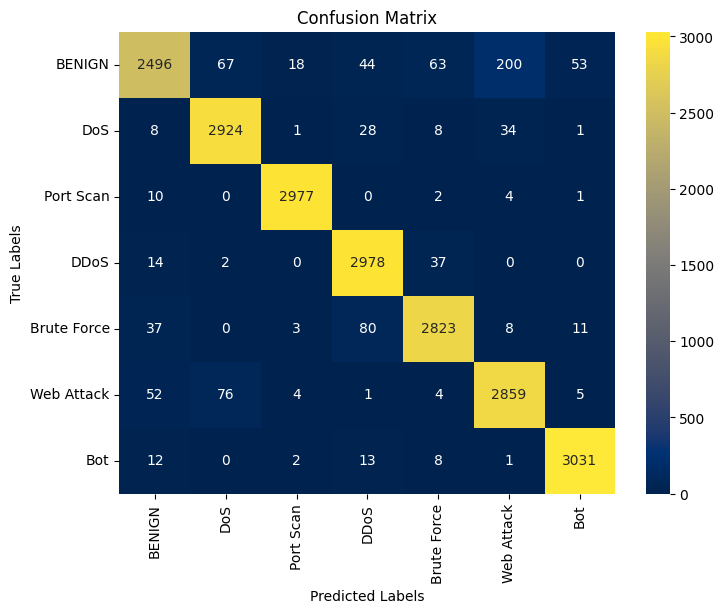

In [42]:
from sklearn.neighbors import KNeighborsClassifier

knn1 = KNeighborsClassifier(n_neighbors = 16)
knn1.fit(X_train, y_train)

cv_knn1 = cross_val_score(knn1, X_train, y_train, cv = 5)
print('K Nearest Neighbors Model 1')
print(f'\nCross-validation scores:', ', '.join(map(str, cv_knn1)))
print(f'\nMean cross-validation score: {cv_knn1.mean():.2f}')

# classification report
y_pred_knn1 = knn1.predict(X_test)
print('K Nearest Neighbors Model 1')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_knn1))

# confusion matrix
cm_knn1 = confusion_matrix(y_test, y_pred_knn1)
print('K Nearest Neighbors Model 1')
print('\nConfusion Matrix:')
plt.figure(figsize = (8, 6))
sns.heatmap(cm_knn1, annot = True, fmt = 'd', cmap = 'cividis', xticklabels = class_names, yticklabels = class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#### Base Neural Network

Epoch 1/20


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


383/383 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2413 - loss: 2092574.8750

2025-06-05 09:39:55.915849: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_49', 8 bytes spill stores, 8 bytes spill loads

2025-06-05 09:39:55.948804: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_49', 12 bytes spill stores, 12 bytes spill loads

2025-06-05 09:39:56.073861: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_49', 112 bytes spill stores, 112 bytes spill loads



383/383 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.2414 - loss: 2089133.7500 - val_accuracy: 0.3172 - val_loss: 1831.7125
Epoch 2/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2350 - loss: 27453.1660 - val_accuracy: 0.1418 - val_loss: 8.3869
Epoch 3/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1722 - loss: 4350.3828 - val_accuracy: 0.1418 - val_loss: 2.0945
Epoch 4/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1545 - loss: 1184.1400 - val_accuracy: 0.1418 - val_loss: 1.9779
Epoch 5/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1499 - loss: 296.1302 - val_accuracy: 0.1418 - val_loss: 1.9461
Epoch 6/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1471 - loss: 202.3411 - val_accuracy: 0.1418 - val_loss: 1.9460
Epoch 7/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1463 - loss: 317.8665 - val_accuracy: 0.1418 - val_loss: 1.9460
Epoch 8/20
383/383 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1455 - loss: 150.8874 

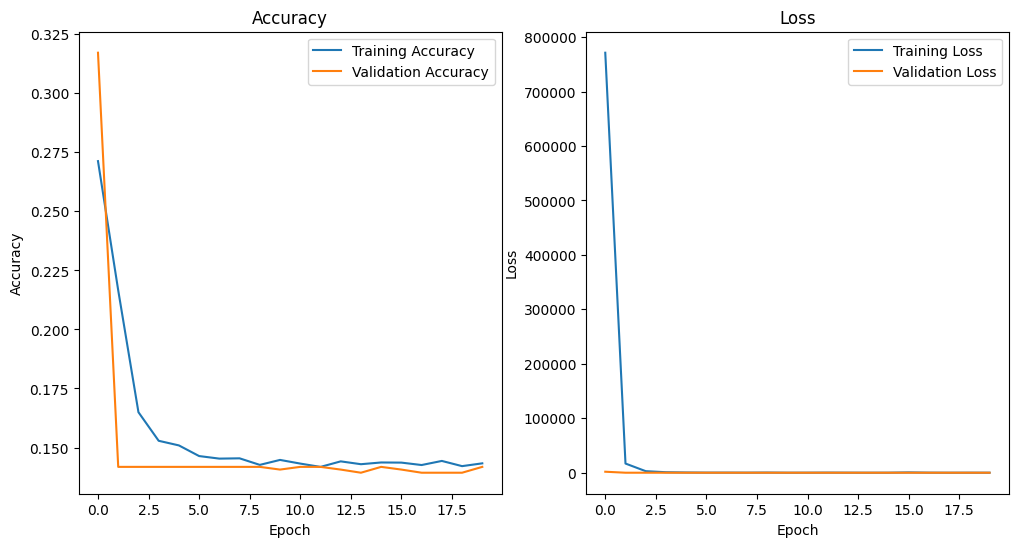

657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/mnt/AI-DATA/alara/CiberIA_O1_A1/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3028
           1       0.00      0.00      0.00      3040
           2       0.00      0.00      0.00      3058
           3       0.00      0.00      0.00      2954
           4       0.00      0.00      0.00      2926
           5       0.14      1.00      0.25      2978
           6       0.00      0.00      0.00      3016

    accuracy                           0.14     21000
   macro avg       0.02      0.14      0.04     21000
weighted avg       0.02      0.14      0.04     21000



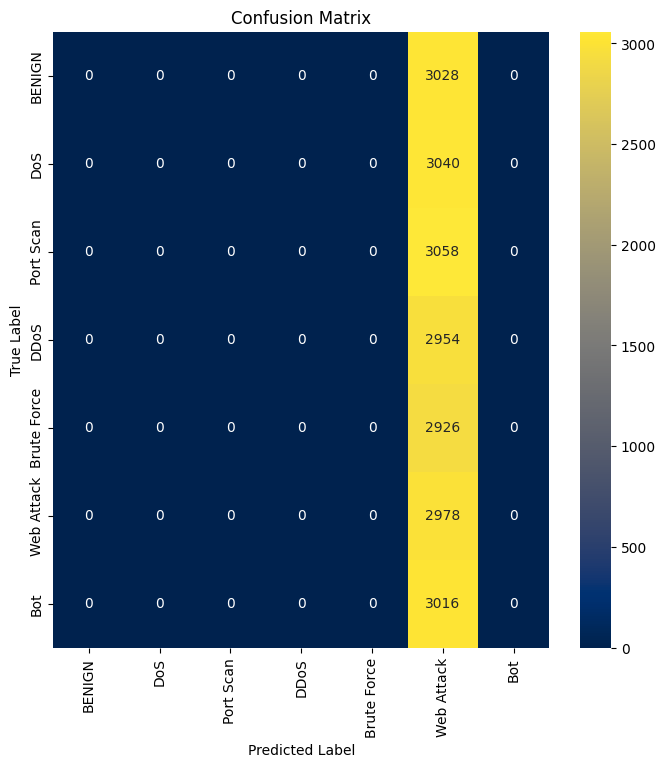

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from time import time


# one hot encoding witout using to_categorical
y_test_cat = pd.get_dummies(y_test)
y_train_cat = pd.get_dummies(y_train)

# Define the model
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(y_train_cat.shape[1], activation='softmax'))

time_start = time()
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train_cat, epochs=20, batch_size=128, validation_data=(X_test, y_test_cat))

time_end = time()
print(f'Training time: {time_end - time_start:.2f} seconds')
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_cat)
print(f'Test Accuracy: {accuracy:.2f}')

# plot accuracy and loss across epochs
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# show classification report

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
y_test_new = np.argmax(y_test_cat.values, axis=1)

print(classification_report(y_test_new, y_pred))

# matrix confusion

cm = confusion_matrix(y_test_new, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### Ensemble method

In [34]:
import lightgbm as lgb
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

params = {
    'min_gain_to_split': 0.1,  # Lowering the threshold for splits
    'min_child_samples': 20,   # Preventing overfitting by controlling sample count per leaf
    'min_data_in_leaf': 30,    # Ensures enough data per leaf
    'num_leaves': 40,
    'max_depth': 15,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,  # Using a fraction of features to prevent overfitting
    'bagging_fraction': 0.8,  # Using a fraction of data to prevent overfitting
    'bagging_freq': 5,  # Perform bagging every iteration
    'random_state': 0,
    'verbose': -1
}

# Create a LightGBM classifier
lgb = lgb.LGBMClassifier(**params)

rf = RandomForestClassifier(n_estimators=200, max_depth=15, criterion='gini', max_features='sqrt')

lr = LogisticRegression(max_iter=20000, C=1.0, penalty='l2', solver='lbfgs', random_state=0)

# Build a stacking classifier with the previously defined RF model (rf1) and LightGBM
stacked_clf = StackingClassifier(
    estimators=[('rf', rf), ('lgbm', lgb)],
    final_estimator=lr,
    cv=5
)

from time import time
start_time = time()
# Train the stacked model
stacked_clf.fit(X_train, y_train)
print(f'\nExecution time: {time() - start_time:.2f} seconds')

# Evaluate via cross-validation
cv_scores = cross_val_score(stacked_clf, X_train, y_train, cv=5)
print('Stacked Model CV Scores:', cv_scores)
print('Mean CV Score:', cv_scores.mean())

# classification report
y_pred_stacked = stacked_clf.predict(X_test)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_stacked))

# confusion matrix
cm_stacked = confusion_matrix(y_test, y_pred_stacked)
print('\nConfusion Matrix:')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_stacked, annot=True, fmt='d', cmap='cividis', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()



Execution time: 71.06 seconds


NameError: name 'cross_val_score' is not defined

In [35]:
# save model into a file
import joblib
model_filename = 'stacked_model_original.pkl'
joblib.dump(stacked_clf, model_filename)
print(f'Model saved to {model_filename}')

Model saved to stacked_model_original.pkl


In [13]:
#load model from a file
import joblib
model_filename = 'stacked_model_original.pkl'
stacked_clf = joblib.load(model_filename)
print("Model loaded successfully.")
print(stacked_clf)

Model loaded successfully.
StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(max_depth=15,
                                                       n_estimators=200)),
                               ('lgbm',
                                LGBMClassifier(bagging_fraction=0.8,
                                               bagging_freq=5,
                                               feature_fraction=0.8,
                                               learning_rate=0.05, max_depth=15,
                                               min_data_in_leaf=30,
                                               min_gain_to_split=0.1,
                                               num_leaves=40, random_state=0,
                                               verbose=-1))],
                   final_estimator=LogisticRegression(max_iter=20000,
                                                      random_state=0))



✅ Batch Simulation Summary
Total batches ingested : 100
Total samples ingested : 345309
Total elapsed time     : 104.36 s
Avg time per batch     : 1.03859 s
Avg time per sample    : 0.00030077 s


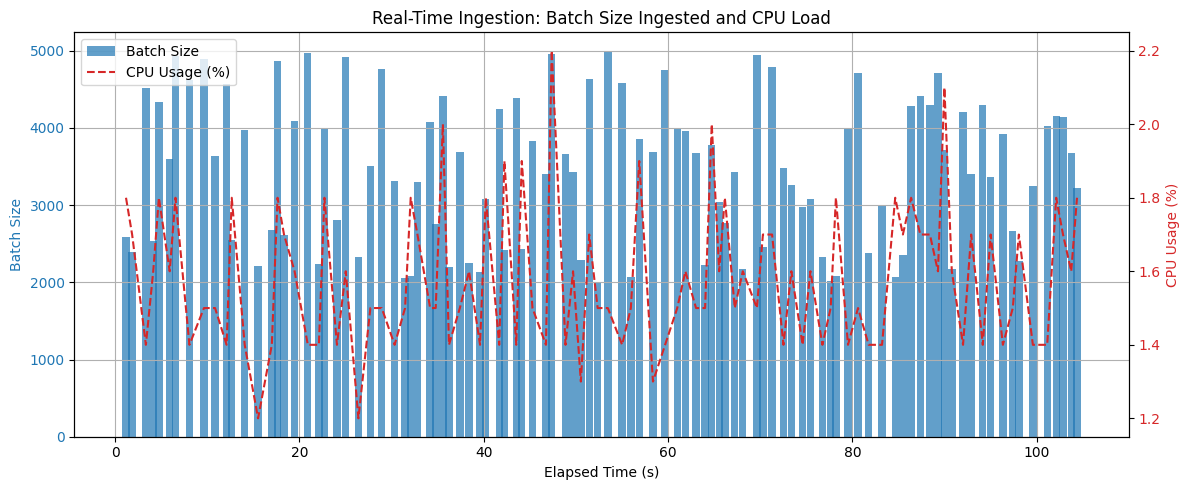

In [14]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import psutil

# STEP 1: Prepare synthetic batches
batch_sizes = np.random.randint(2000, 5000, size=100)
batches = [blnc_data.sample(n=size, random_state=i) for i, size in enumerate(batch_sizes)]

# Storage
prediction_times = []
batch_sizes_recorded = []
time_stamps = []
cpu_usages = []

sim_start = time.time()

for batch in batches:
    batch = batch.copy()
    X_batch = batch.drop('Attack Type', axis=1)

    # Add feature-space noise: 10% samples, 20% features
    n_samples = int(0.1 * len(X_batch))
    n_features = int(0.2 * X_batch.shape[1])
    noise_idx = np.random.choice(X_batch.index, size=n_samples, replace=False)
    feat_idx  = np.random.choice(X_batch.columns, size=n_features, replace=False)
    for col in feat_idx:
        std = X_batch[col].std()
        noise = np.random.uniform(-0.1*std, 0.1*std, size=n_samples).astype(X_batch[col].dtype)
        X_batch.loc[noise_idx, col] += noise

    # Predict & record CPU
    t0 = time.time()
    io_delay = np.random.uniform(0.5,1.5)
    time.sleep(io_delay)
    _ = stacked_clf.predict(X_batch)
    t1 = time.time()

    prediction_times.append(t1 - t0)
    batch_sizes_recorded.append(len(batch))
    time_stamps.append(t1 - sim_start)
    cpu_usages.append(psutil.cpu_percent(interval=None))

# Total elapsed
total_elapsed = time.time() - sim_start
total_batches = len(batch_sizes_recorded)
total_samples = sum(batch_sizes_recorded)
avg_batch_time = np.mean(prediction_times)
avg_sample_time = sum(prediction_times) / total_samples

print("\n✅ Batch Simulation Summary")
print(f"Total batches ingested : {total_batches}")
print(f"Total samples ingested : {total_samples}")
print(f"Total elapsed time     : {total_elapsed:.2f} s")
print(f"Avg time per batch     : {avg_batch_time:.5f} s")
print(f"Avg time per sample    : {avg_sample_time:.8f} s")

# Plot batch size and CPU usage
fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()

# Batch size over time
ax1.bar(time_stamps, batch_sizes_recorded, color='tab:blue', alpha=0.7, label='Batch Size')
ax1.set_xlabel("Elapsed Time (s)")
ax1.set_ylabel("Batch Size", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# CPU usage over time
ax2.plot(time_stamps, cpu_usages, color='tab:red', linestyle='--', label='CPU Usage (%)')
ax2.set_ylabel("CPU Usage (%)", color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_title("Real-Time Ingestion: Batch Size Ingested and CPU Load")
ax1.grid(True)
fig.tight_layout()
plt.savefig('batch_ingestion_cpu_load.png', dpi=500)


#### RONI

In [ ]:
import numpy as np
import pandas as pd
import warnings
from time import time
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans

# Suppress the "feature names mismatch" warning
warnings.filterwarnings(
    "ignore",
    message="X has feature names, but LogisticRegression was fitted without feature names"
)

##############################################################################
# 1. Create (or load) a small dataset
##############################################################################

# Convert to DataFrame / Series for convenience
features = pd.DataFrame(features)
labels = pd.Series(labels)

# We sample 2% of the data to keep things small in this demo:
features_sample = features.sample(frac=0.01, random_state=0)
labels_sample = labels.loc[features_sample.index]

##############################################################################
# 2. Introduce 10 malicious ("bad") samples
##############################################################################
# In a real attack, an adversary might craft these more subtly. 
# Here, we simply:
# - Create 10 samples of all zeros (feature vectors).
# - Assign them a label "BENIGN" (which may or may not be correct for your domain).
num_bad = 10
X_bad = np.zeros((num_bad, features_sample.shape[1]))
# Let's label them all "BENIGN"
y_bad = ['BENIGN'] * num_bad

# Convert to DataFrame/Series so we can easily append
X_bad_df = pd.DataFrame(X_bad, columns=features_sample.columns)
y_bad_sr = pd.Series(y_bad)

# Append bad samples to the "features_sample" and "labels_sample"
features_with_bad = pd.concat([features_sample, X_bad_df], ignore_index=True)
labels_with_bad = pd.concat([labels_sample, y_bad_sr], ignore_index=True)

##############################################################################
# 3. Split into train / test
##############################################################################
X_train, X_test, y_train, y_test = train_test_split(
    features_with_bad,
    labels_with_bad,
    test_size=0.2,
    random_state=42
)

# Further split training into (train_main / validation)
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, 
    y_train, 
    test_size=0.2, 
    random_state=42
)

print(f"Train main set size: {len(X_train_main)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}\n")

##############################################################################
# 4. Train a baseline model (SVC in this example)
##############################################################################
start_time = time()

baseline_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=10000)
baseline_model.fit(X_train_main, y_train_main)

baseline_acc = accuracy_score(y_val, baseline_model.predict(X_val))
print(f"Baseline validation accuracy: {baseline_acc:.3f}")

##############################################################################
# 5. Naive RONI detection: remove each sample, re-train, check validation
##############################################################################
negatively_influential_indices = []

# We'll track the indices of the malicious samples in X_train_main.
# Because we appended malicious samples at the end of 'features_sample',
# we know their original indices in the concatenated DataFrame start at:
original_len = len(features_sample)  # number of rows *before* adding 10 bad

train_indices = X_train_main.index  # these are the (original) row indices
bad_indices_in_train = []
for local_i, idx in enumerate(train_indices):
    if idx >= original_len:
        # idx >= original_len => It's one of the appended "bad" samples
        bad_indices_in_train.append(local_i)

# Now we do the naive RONI procedure
# We'll use LogisticRegression for speed in the RONI loop
for i in range(len(X_train_main)):
    # Remove the i-th sample from the training set
    X_minus_one = np.delete(X_train_main.to_numpy(), i, axis=0)
    y_minus_one = np.delete(y_train_main.to_numpy(), i)

    # Retrain quickly on the remaining data
    temp_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=10000)
    temp_model.fit(X_minus_one, y_minus_one)

    # Check validation accuracy
    temp_acc = accuracy_score(y_val, temp_model.predict(X_val))

    # If removing this sample improves validation accuracy by > 5%,
    # we consider it negatively influential. Adjust threshold as you wish.
    if temp_acc > 1.05* baseline_acc:
        negatively_influential_indices.append(i)

print(f"Number of negatively influential samples (RONI): {len(negatively_influential_indices)}")

##############################################################################
# 6. Compute RONI detection statistics
##############################################################################
detected_bad_samples_roni = set(bad_indices_in_train).intersection(negatively_influential_indices)
num_detected_bad_roni = len(detected_bad_samples_roni)

# Detection accuracy = fraction of malicious samples that were caught
detection_accuracy_roni = (
    num_detected_bad_roni / len(bad_indices_in_train) 
    if bad_indices_in_train 
    else 0.0
)

# Number of errors (false positives) = total flagged - truly malicious among them
false_positives_roni = len(negatively_influential_indices) - num_detected_bad_roni

print("=== RONI Results ===")
print(f"Malicious samples actually in train_main: {bad_indices_in_train}")
print(f"Malicious samples detected by RONI: {detected_bad_samples_roni}")
print(f"RONI detection accuracy: {detection_accuracy_roni:.3f}")
print(f"RONI false positives (benign flagged as bad): {false_positives_roni}\n")
print(f"RONI Execution time: {time() - start_time:.2f} seconds\n")

##############################################################################
# 7. Retrain after RONI removal
##############################################################################
X_train_cleaned_roni = np.delete(X_train_main.to_numpy(), negatively_influential_indices, axis=0)
y_train_cleaned_roni = np.delete(y_train_main.to_numpy(), negatively_influential_indices)

final_model_roni = LogisticRegression(solver='liblinear', random_state=42, max_iter=10000)
final_model_roni.fit(X_train_cleaned_roni, y_train_cleaned_roni)

final_val_acc_roni = accuracy_score(y_val, final_model_roni.predict(X_val))
final_test_acc_roni = accuracy_score(y_test, final_model_roni.predict(X_test))

print("=== Performance after RONI ===")
print(f"Final validation accuracy after RONI: {final_val_acc_roni:.3f}")
print(f"Test accuracy after RONI: {final_test_acc_roni:.3f}")

##############################################################################
# 8. Clustering-based Detection (K-Means)
##############################################################################
# We'll use a simple approach:
#   1) Fit K-Means on the training data.
#   2) For each sample, compute distance to its assigned cluster centroid.
#   3) Label "outliers" as those with distance above (mean + 2 * std) 
#      in their assigned cluster. 
# In practice, you might choose # of clusters differently or use DBSCAN, etc.
start_time = time()
kmeans = KMeans(n_clusters=2, random_state=42)
train_array = X_train_main.to_numpy()

# Fit K-Means
kmeans.fit(train_array)

# For each sample, find its assigned cluster centroid
labels_km = kmeans.labels_             # cluster assignment
centers = kmeans.cluster_centers_      # shape: (n_clusters, n_features)

# Compute distances to the assigned centroid
distances = np.zeros(len(train_array))
for i, c_label in enumerate(labels_km):
    centroid = centers[c_label]
    dist = np.linalg.norm(train_array[i] - centroid)
    distances[i] = dist

# We'll define an outlier threshold per cluster: mean + 2*std of distances
outlier_thresholds = {}
for cluster_id in range(2):
    cluster_dists = distances[labels_km == cluster_id]
    mu = cluster_dists.mean()
    sigma = cluster_dists.std()
    outlier_thresholds[cluster_id] = mu + 2 * sigma

# Flag samples whose distance > threshold for their cluster
clustering_influential_indices = []
for i, c_label in enumerate(labels_km):
    if distances[i] > outlier_thresholds[c_label]:
        clustering_influential_indices.append(i)

print(f"\nNumber of negatively influential samples (Clustering): "
      f"{len(clustering_influential_indices)}")

##############################################################################
# 9. Compute Clustering detection statistics
##############################################################################
detected_bad_samples_cluster = (
    set(bad_indices_in_train).intersection(clustering_influential_indices)
)
num_detected_bad_cluster = len(detected_bad_samples_cluster)

detection_accuracy_cluster = (
    num_detected_bad_cluster / len(bad_indices_in_train) 
    if bad_indices_in_train 
    else 0.0
)

false_positives_cluster = len(clustering_influential_indices) - num_detected_bad_cluster

print("=== Clustering Results ===")
print(f"Malicious samples actually in train_main: {bad_indices_in_train}")
print(f"Malicious samples detected by Clustering: {detected_bad_samples_cluster}")
print(f"Clustering detection accuracy: {detection_accuracy_cluster:.3f}")
print(f"Clustering false positives: {false_positives_cluster}")
print(f"Clustering Execution time: {time() - start_time:.2f} seconds\n")

##############################################################################
# 10. Retrain after Clustering-based removal (optional)
##############################################################################
X_train_cleaned_cluster = np.delete(train_array, clustering_influential_indices, axis=0)
y_train_cleaned_cluster = np.delete(y_train_main.to_numpy(), clustering_influential_indices)

final_model_cluster = SVC(kernel='rbf', C=1, random_state=42, probability=True)
final_model_cluster.fit(X_train_cleaned_cluster, y_train_cleaned_cluster)

final_val_acc_cluster = accuracy_score(y_val, final_model_cluster.predict(X_val))
final_test_acc_cluster = accuracy_score(y_test, final_model_cluster.predict(X_test))

print("\n=== Performance after Clustering-based Removal ===")
print(f"Final validation accuracy after Clustering: {final_val_acc_cluster:.3f}")
print(f"Test accuracy after Clustering: {final_test_acc_cluster:.3f}")

print(f"\nExecution time: {time() - start_time:.2f} seconds")


In [ ]:
import numpy as np
import pandas as pd
import warnings
from time import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

##############################################################################
# 1. Convert your (already loaded) data into DataFrame / Series
##############################################################################
# (Assuming `features` and `labels` are already loaded in your environment.)

features = pd.DataFrame(features)
labels = pd.Series(labels)

# Sample 2% of your dataset, as in your snippet
features_sample = features.sample(frac=0.01, random_state=0)
labels_sample = labels.loc[features_sample.index]

##############################################################################
# 2. Inject 10 Malicious ("Bad") Samples
##############################################################################
num_bad = 10
X_bad = np.zeros((num_bad, features_sample.shape[1]))
y_bad = ['BENIGN'] * num_bad

X_bad_df = pd.DataFrame(X_bad, columns=features_sample.columns)
y_bad_sr = pd.Series(y_bad)

features_with_bad = pd.concat([features_sample, X_bad_df], ignore_index=True)
labels_with_bad = pd.concat([labels_sample, y_bad_sr], ignore_index=True)

##############################################################################
# 3. Split into Train / Test, then Train / Validation
##############################################################################
X_train, X_test, y_train, y_test = train_test_split(
    features_with_bad, 
    labels_with_bad, 
    test_size=0.2, 
    random_state=42
)

X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print(f"Train main set size: {len(X_train_main)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}\n")

start_time = time()

##############################################################################
# 4. Baseline Model (SVC)
##############################################################################
baseline_model = SVC(kernel='rbf', C=1, random_state=42, probability=True)
baseline_model.fit(X_train_main, y_train_main)

baseline_acc = accuracy_score(y_val, baseline_model.predict(X_val))
print(f"Baseline validation accuracy: {baseline_acc:.3f}")

##############################################################################
# 5. Identify Which Training Samples Are Malicious
#    (Because we appended them last, their 'original' index >= len(features_sample))
##############################################################################
original_len = len(features_sample)  # # rows before adding the 10 bad
train_indices = X_train_main.index

bad_indices_in_train = []  # local indices of malicious samples in X_train_main
for local_i, idx in enumerate(train_indices):
    if idx >= original_len:  # it means it's one of the appended "bad" samples
        bad_indices_in_train.append(local_i)

##############################################################################
# 6. Clustering Step to Identify "Suspicious" Samples
##############################################################################
kmeans = KMeans(n_clusters=2, random_state=42)
train_array = X_train_main.to_numpy()

kmeans.fit(train_array)
cluster_assignments = kmeans.labels_
centers = kmeans.cluster_centers_

# Compute distance to assigned centroid
distances = np.array([
    np.linalg.norm(train_array[i] - centers[cluster_assignments[i]])
    for i in range(len(train_array))
])

# We'll define an outlier threshold per cluster as mean + 2*std
outlier_thresholds = {}
for clust_id in range(2):
    dists_in_clust = distances[cluster_assignments == clust_id]
    mu = dists_in_clust.mean()
    sigma = dists_in_clust.std()
    outlier_thresholds[clust_id] = mu + 2 * sigma

# Flag samples whose distance > threshold as suspicious
suspicious_indices_cluster = []
for i, c_label in enumerate(cluster_assignments):
    if distances[i] > outlier_thresholds[c_label]:
        suspicious_indices_cluster.append(i)

print(f"\nNumber of suspicious samples (Clustering): {len(suspicious_indices_cluster)}")

##############################################################################
# 7. Hybrid RONI: Apply RONI ONLY to the clustering-identified suspicious subset
##############################################################################
negatively_influential_indices = []

# We'll iterate over the suspicious indices identified by clustering
for i in suspicious_indices_cluster:
    # Remove the i-th sample from X_train_main
    X_minus_one = np.delete(train_array, i, axis=0)
    y_minus_one = np.delete(y_train_main.to_numpy(), i)

    # Retrain quickly (LogisticRegression) and compare to baseline_acc
    temp_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=10000)
    temp_model.fit(X_minus_one, y_minus_one)
    temp_acc = accuracy_score(y_val, temp_model.predict(X_val))

    # If removing this sample improves validation accuracy >5%, mark as malicious
    if temp_acc > 1.05 * baseline_acc:
        negatively_influential_indices.append(i)

num_detected_hybrid = len(negatively_influential_indices)
print(f"\nNumber of negatively influential samples (Hybrid Approach): {num_detected_hybrid}")

##############################################################################
# 8. Hybrid Detection Statistics
##############################################################################
detected_bad_samples_hybrid = set(bad_indices_in_train).intersection(negatively_influential_indices)
num_detected_bad_hybrid = len(detected_bad_samples_hybrid)

total_bad_in_train = len(bad_indices_in_train)
detection_accuracy_hybrid = (
    num_detected_bad_hybrid / total_bad_in_train 
    if total_bad_in_train > 0 
    else 0.0
)

false_positives_hybrid = num_detected_hybrid - num_detected_bad_hybrid

print("\n=== Hybrid Detection Results (Clustering + RONI) ===")
print(f"Malicious samples in train_main: {bad_indices_in_train}")
print(f"Malicious samples detected: {detected_bad_samples_hybrid}")
print(f"Detection accuracy: {detection_accuracy_hybrid:.3f}")
print(f"False positives: {false_positives_hybrid}")

##############################################################################
# 9. Retrain Model After Hybrid Removal (Optional)
##############################################################################
X_train_cleaned_hybrid = np.delete(train_array, negatively_influential_indices, axis=0)
y_train_cleaned_hybrid = np.delete(y_train_main.to_numpy(), negatively_influential_indices)

final_model_hybrid = SVC(kernel='rbf', C=1, random_state=42, probability=True)
final_model_hybrid.fit(X_train_cleaned_hybrid, y_train_cleaned_hybrid)

final_val_acc_hybrid = accuracy_score(y_val, final_model_hybrid.predict(X_val))
final_test_acc_hybrid = accuracy_score(y_test, final_model_hybrid.predict(X_test))

print("\n=== Performance After Hybrid Removal ===")
print(f"Validation accuracy (Hybrid): {final_val_acc_hybrid:.3f}")
print(f"Test accuracy (Hybrid): {final_test_acc_hybrid:.3f}")

print(f"\nExecution time: {time() - start_time:.2f} seconds")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
sns.set_palette('Set2')

##############################################################################
# 1) Define your data as lists of (label, value) tuples.
##############################################################################
precision_data = [
    ("RONI-SVM",   0.95),
    ("RONI-RF",    0.93),
    ("RONI-LR",    0.94),
    ("CLUST",     0.57),
    ("HYBRID-SVM",  0.94),
    ("HYBRID-RF",   0.93),
    ("HYBRID-LR",   0.96),
]
sensitivity_data = [
    ("RONI-SVM",   0.67),
    ("RONI-RF",    0.63),
    ("RONI-LR",    0.71),
    ("CLUST",     0.96),
    ("HYBRID-SVM",  0.69),
    ("HYBRID-RF",   0.65),
    ("HYBRID-LR",   0.71),
]
time_data = [
    ("RONI-SVM",   393.8),
    ("RONI-RF",    808.8),
    ("RONI-LR",    751.3),
    ("CLUST",       2.3),
    ("HYBRID-SVM", 125.2),
    ("HYBRID-RF",  569.1),
    ("HYBRID-LR",   65.2),
]

##############################################################################
# 2) Sort each list:
#    - Precision  => ascending
#    - Sensitivity => ascending
#    - Runtime    => descending
##############################################################################
precision_data_sorted   = sorted(precision_data,   key=lambda x: x[1])          # ascending
sensitivity_data_sorted = sorted(sensitivity_data, key=lambda x: x[1])          # ascending
time_data_sorted        = sorted(time_data,        key=lambda x: x[1], reverse=True)  # descending

# Extract just the values (and labels) in sorted order:
p_labels,  p_vals  = zip(*precision_data_sorted)
s_labels,  s_vals  = zip(*sensitivity_data_sorted)
t_labels,  t_vals  = zip(*time_data_sorted)

##############################################################################
# 3) We create a single figure with:
#    - x-axis: three "groups" => Precision, Sensitivity, Runtime
#    - left y-axis (0..1) for Precision & Sensitivity
#    - right y-axis for Time
##############################################################################
fig, ax1 = plt.subplots(figsize=(10,5))  # ax1 -> left axis
ax2 = ax1.twinx()                        # ax2 -> right axis

# We'll define x positions for each group (each group has 7 bars).
# e.g., group1_x => 0..6, group2_x => 8..14, group3_x => 16..22
group_size = 7
gap = 1.5  # Gap between groups

group1_x = np.arange(group_size)                   # 0..6
group2_x = group1_x + (group_size + gap)           # 8..14
group3_x = group2_x + (group_size + gap)           # 16..22

# Assign a unique color per label
unique_labels = list(set(p_labels + s_labels + t_labels))
label_colors = {label: plt.cm.tab20(i/len(unique_labels)) for i, label in enumerate(unique_labels)}

# Plot bars for Precision (group1_x, on ax1)
bars_prec = ax1.bar(
    group1_x, 
    p_vals,
    color=[label_colors[label] for label in p_labels],
    width=0.8
)

# Plot bars for Sensitivity (group2_x, on ax1)
bars_sens = ax1.bar(
    group2_x,
    s_vals,
    color=[label_colors[label] for label in s_labels],
    width=0.8
)

# Plot bars for Runtime (group3_x, on ax2)
bars_time = ax2.bar(
    group3_x,
    t_vals,
    color=[label_colors[label] for label in t_labels],
    width=0.8
)

##############################################################################
# 4) Annotate the bars (optional) with label & numeric value
##############################################################################
def annotate_bars(ax, bars, labels, values, offset_factor=0.01):
    max_val = max(values) if values else 1
    for bar, lbl, val in zip(bars, labels, values):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + offset_factor*max_val,
            f"{lbl}\n{val}",
            ha='center',
            va='bottom',
            fontsize=8,
            rotation=90
        )

# Annotate Precision & Sensitivity on ax1
annotate_bars(ax1, bars_prec, p_labels, p_vals)
annotate_bars(ax1, bars_sens, s_labels, s_vals)

# Annotate Runtime on ax2
annotate_bars(ax2, bars_time, t_labels, t_vals, offset_factor=0.03)

##############################################################################
# 5) Configure X-axis
#    We'll place ticks at the midpoint of each group
##############################################################################
ax1.set_xticks([
    group1_x.mean(), 
    group2_x.mean(), 
    group3_x.mean()
])
ax1.set_xticklabels(["Precision", "Sensitivity", "Runtime"])

##############################################################################
# 6) Configure Y-axis ranges
#    - Left (ax1): 0..1.1 for P & S
#    - Right (ax2): auto or up to some maximum for time
##############################################################################
ax1.set_ylim(0, 1.15)   # Because precision & sensitivity are between 0..1
ax1.set_ylabel("Precision / Sensitivity")

max_time = max(t_vals) if t_vals else 1
ax2.set_ylim(0, max_time * 1.2)
ax2.set_ylabel("Time (s)")

##############################################################################
# 7) Styling & Legends Removed
##############################################################################
ax1.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('roni_comparison.png',dpi=500)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# Data from TABLE 2
# (LR[RF+LGBM], NN+LR[RF+LGBM])
# ----------------------------------
# Rows (6 total): 
#   1) NO-SMOTE + PCA(37)
#   2) NO-SMOTE + Top 20 IG
#   3) NO-SMOTE + Top 40 IG
#   4) SMOTE + PCA(37)
#   5) SMOTE + Top 20 IG
#   6) SMOTE + Top 40 IG

labels_table2 = [
    'NO-SMOTE\nPCA(37)',
    'NO-SMOTE\nTop 20 IG',
    'NO-SMOTE\nTop 40 IG',
    'SMOTE\nPCA(37)',
    'SMOTE\nTop 20 IG',
    'SMOTE\nTop 40 IG'
]

# Accuracy
acc_lr =       [0.85,    0.96,   0.992,   0.9995, 0.9994, 0.9996]
acc_nn_lr =    [0.94,    0.87,   0.76,    0.9998, 0.84,   0.86]

# F1-score
f1_lr =        [0.85,    0.96,   0.96,    0.9994, 0.9991, 0.9994]
f1_nn_lr =     [0.93,    0.85,   0.74,    0.9998, 0.78,   0.84]

# Time
time_lr =      [267,    37,     54.5,   235.1, 55,   91]
time_nn_lr =   [312,    36.8,   40.4,   285.4, 59.1, 62.5]


def add_labels(ax, rects, fmt='{:.4f}'):
    """
    Attach a text label above each bar, displaying its height.
    :param ax: Matplotlib axes object
    :param rects: List of bar rectangle objects
    :param fmt: Format string for numeric labels
    """
    for rect in rects:
        height = rect.get_height()
        ax.annotate(fmt.format(height),
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),       # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)


# ------------------------
# Plotting: TABLE 2
# ------------------------
x2 = np.arange(len(labels_table2))
width2 = 0.35

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)

# --- Accuracy subplot ---
ax_acc2 = axes2[0]
ax_acc2.set_title('Accuracy')
rects_lr_acc = ax_acc2.bar(x2 - width2/2, acc_lr,    width2, label='LR[RF+LGBM]')
rects_nn_acc = ax_acc2.bar(x2 + width2/2, acc_nn_lr, width2, label='NN+LR[RF+LGBM]')
ax_acc2.set_xticks(x2, labels_table2, rotation=15, ha='right')
ax_acc2.set_ylim([0, 1.05])
ax_acc2.set_ylabel('Accuracy')
ax_acc2.legend(loc='lower right')

# Add numeric labels
add_labels(ax_acc2, rects_lr_acc)
add_labels(ax_acc2, rects_nn_acc)

# --- Time subplot ---
ax_time2 = axes2[1]
ax_time2.set_title('Training Time')
rects_lr_time = ax_time2.bar(x2 - width2/2, time_lr,    width2, label='LR[RF+LGBM]')
rects_nn_time = ax_time2.bar(x2 + width2/2, time_nn_lr, width2, label='NN+LR[RF+LGBM]')
ax_time2.set_xticks(x2, labels_table2, rotation=15, ha='right')
ax_time2.set_ylabel('Time (seconds)')
ax_time2.legend()

# Add numeric labels
# Use a different format for time if you want fewer decimals, e.g. '{:.1f}'
add_labels(ax_time2, rects_lr_time, fmt='{:.1f}')
add_labels(ax_time2, rects_nn_time, fmt='{:.1f}')

# Figure title, save, and show
plt.savefig('table2.png', dpi=500)
plt.show()


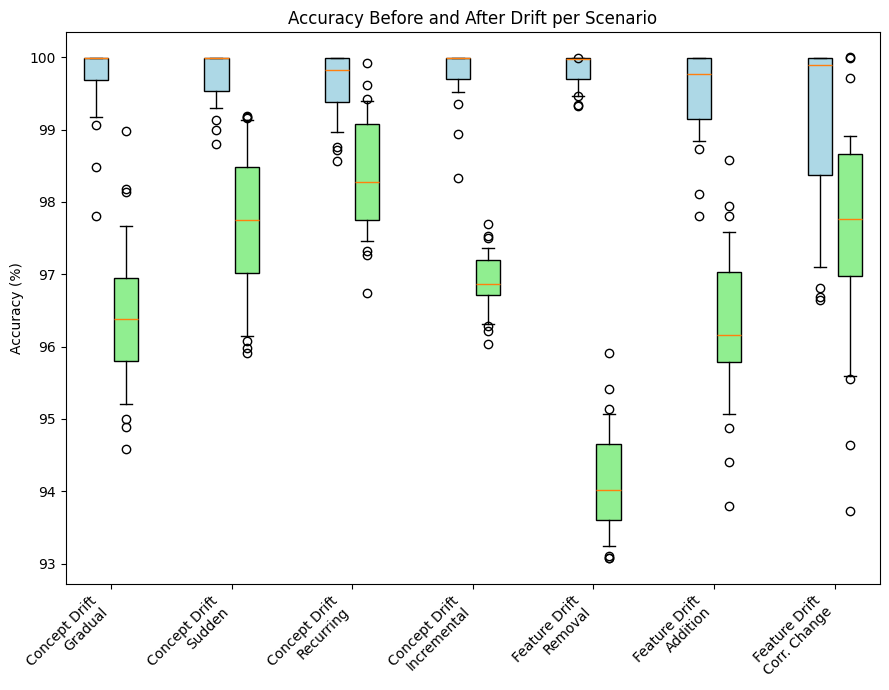

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data from the table ---
drift_types = [
    "Concept Drift", "Concept Drift", "Concept Drift", "Concept Drift",
    "Feature Drift", "Feature Drift", "Feature Drift"
]
drift_scenarios = [
    "Gradual", "Sudden", "Recurring", "Incremental",
    "Removal", "Addition", "Corr. Change"
]
accuracies_before = [99.98, 99.98, 99.99, 99.99, 99.98, 99.98, 99.98]  # in %
accuracies_after  = [96.80, 97.25, 98.62, 97.00, 94.12, 96.55, 97.58]   # in %

# --- Generate synthetic distributions ---
# (We simulate 30 samples per box for demonstration purposes)
np.random.seed(0)
num_samples = 30
std_accuracy = 0.25  # small std to simulate minor variation

all_data = []     # synthetic data for each boxplot
group_labels = [] # labels for each scenario group (drift type and scenario)
box_positions = []# positions for each of the 14 boxplots
box_colors = []   # colors: one for "Before" and one for "After"

# Use positions that are closer together:
# For each scenario, "Before" at pos = i*2 + 1, "After" at pos = i*2 + 1.5
for i in range(len(drift_types)):
    pos_before = i * 2 + 1
    pos_after  = i * 2 + 1.5
    box_positions.extend([pos_before, pos_after])
    
    # Synthetic data for "Before" and "After" accuracies
    data_before = np.random.normal(loc=accuracies_before[i], scale=np.random.uniform(0.3,1.5), size=num_samples)
    data_after  = np.random.normal(loc=accuracies_after[i], scale=np.random.uniform(0.3,1.5), size=num_samples)

    # if anym value is > 1, set it to 0.99
    data_before[data_before > 100] = 99.99
    data_after[data_after > 100] = 99.99
    all_data.append(data_before)
    all_data.append(data_after)
    
    # Label only with drift type and scenario
    label = f"{drift_types[i]}\n{drift_scenarios[i]}"
    group_labels.append(label)
    
    # Define colors: lightblue for "Before", lightgreen for "After"
    box_colors.extend(["lightblue", "lightgreen"])

# --- Create the figure and boxplots ---
fig, ax = plt.subplots(figsize=(9, 7))  # shorter height for better whisker visibility

# Set whiskers to the 10th and 90th percentiles
bp = ax.boxplot(all_data, positions=box_positions, widths=0.4, whis=[10, 90], patch_artist=True)

# Color each box
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)

# Set x-axis ticks at the center of each group
# Center position = (i*2 + 1 + i*2 + 1.5) / 2 = i*2 + 1.25
group_positions = [i * 2 + 1.25 for i in range(len(drift_types))]
ax.set_xticks(group_positions)
ax.set_xticklabels(group_labels, fontsize=10, rotation=45, ha="right")

ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy Before and After Drift per Scenario")

plt.tight_layout()
plt.savefig('boxplot_drift.png', dpi=500)
